#### Processing UTI cellular markers


#### Loading packages

In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import re
from skimage.exposure import adjust_gamma
from tqdm.auto import tqdm

from PyPlaque.experiment import CrystalViolet
from PyPlaque.specimen import PlaquesImageGray, PlaquesMask
from PyPlaque.view import PlateImage
from PyPlaque.utils import (stitch_wells, centroid, compare_plaque_detection_from_image,
                                                plot_bbox_plaques_mask, boxplot_quants)

/Users/de29/Applications/miniforge3/envs/pyplaque/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### Initialising parameters and data
###### Since we would now like to get the readouts and see the usefulness other functionalities from PyPlaque for a Crystal Violet Plate, we define a new ```CrystalViolet``` class instance to work with them.<br> ```base_dir``` is folder above the image and mask folders for all the plates. ```params``` are set to None to choose using the default parameters but values can be updated. <br>Using ```exp.get_individual_plates()``` we get the individual plate and plate mask folders for the given pattern and ```exp.get_number_of_plates()``` gives us the number of plates found according to the ```folder_pattern``` regex (https://docs.python.org/3/howto/regex.html), here just 1. The maximum number of wells per channel here for the data we have considered is 6.

In [3]:
# Loading multiple plates and plate masks as an experiment
base_dir = '../../../../DeepUTI/ds1/test/'

exp = CrystalViolet(base_dir+'img/', base_dir+'man_mask/',
                                        params = None) # default values in class, option to update

In [4]:
# In this case, the individual plate is the urine microscopy images and
# their corresponding mask directories. Make sure to have similar directories for 
# images and masks(even if empty)
plate_dirs, plate_mask_dirs = exp.get_individual_plates(folder_pattern=r'cls$')

print(plate_dirs, plate_mask_dirs)

# We are choosing via the pattern above to ignore all other plates other than this one
print(exp.get_number_of_plates())

['cls'] ['cls']
1


#### UTI cellular marker Images and Masks
###### ```exp.load_well_images_and_masks_for_plate()``` helps us load into memory all data for the cellular markers, corresponding to the given index from the plates found ```plate_id``` and file pattern ```file_pattern```. Here the mask path is not empty for us but they can also be generated from images as we will show later. Unlike in Fluorescent Plate we do not generate these by default if missing since it is a little more difficult in this case and it is up to the user whether to use it after seeing the results below.

In [5]:
#Example considering all data from the selected plate
plate_dict = exp.load_well_images_and_masks_for_plate(plate_id=0, additional_subfolders=None, ext='*.tif') # Default ext='*.png'
print(plate_dict.keys())

100it [00:00, 99179.57it/s]
100%|██████████| 100/100 [00:00<00:00, 189.12it/s]
100it [00:00, 94872.29it/s]
100%|██████████| 100/100 [00:00<00:00, 314.40it/s]

dict_keys(['cls'])


###### We then show the image name, image and mask from the loaded data.

../../../../DeepUTI/ds1/test/img/cls/130 G 261021.tif


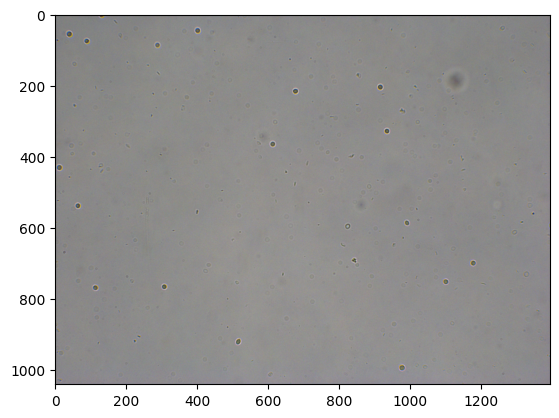

In [6]:
print(plate_dict[plate_dirs[0]]['image_name'][0])
plt.imshow(plate_dict[plate_dirs[0]]['img'][0])

../../../../DeepUTI/ds1/test/img/cls/130 G 261021.tif


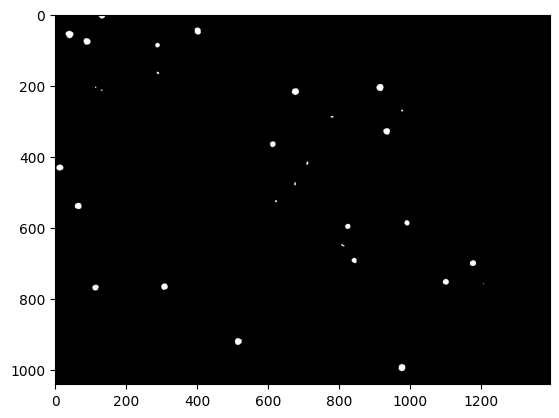

In [7]:
print(plate_dict[plate_dirs[0]]['image_name'][0])
plt.imshow(plate_dict[plate_dirs[0]]['mask'][0], cmap='gray')

#### Grayscale Images and Masks
###### ```exp.load_well_images_and_masks_for_plate()``` also has the option to load into memory all data for the crystal violet plate in grayscale using the ```all_grayscale``` flag. This is particularly useful because it reduces our computation cost due to single channel instead of multi-channel images and is necessary for certain functionalities such as eccentricity readouts of plaques in a well.<br> We then verify the number of images read and show an image name, image from the loaded data for the plate.

In [8]:
# Example considering all wells from the selected plate reading images also in grayscale
plate_dict = exp.load_well_images_and_masks_for_plate(plate_id=0, additional_subfolders=None,
                                                            all_grayscale=True, file_pattern=None, ext='*.tif')
print(plate_dict.keys())

100it [00:00, 152464.70it/s]
100%|██████████| 100/100 [00:00<00:00, 122.41it/s]
100it [00:00, 159479.24it/s]
100%|██████████| 100/100 [00:00<00:00, 188.33it/s]

dict_keys(['cls'])


../../../../DeepUTI/ds1/test/img/cls/130 G 261021.tif


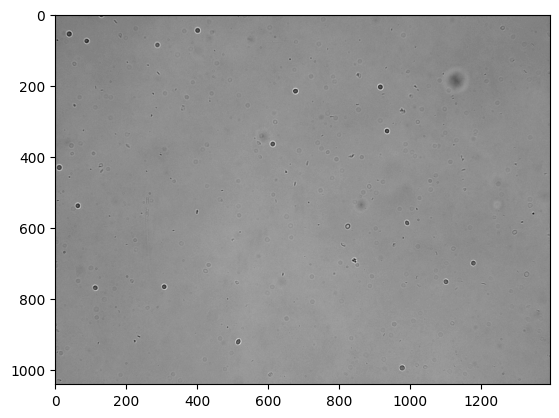

In [9]:
print(plate_dict[plate_dirs[0]]['image_name'][0])
plt.imshow(plate_dict[plate_dirs[0]]['img'][0], cmap='gray')

###### We can use the function ```exp.extract_masked_wells()``` to get the masked image of the microscope field that helps us to get an unobstructed view of the cellular objects without the background of the plate, medium or any other noise.<br> Here we take the image from index 0 of the plate dictionary ```plate_dict``` and show the masked plaques in it.

In [10]:
# Assuming that wells were numbered in raster scan fashion from left to right, row by row
plate_dict = exp.extract_masked_wells(plate_id=0)

100%|██████████| 100/100 [00:00<00:00, 846.72it/s]


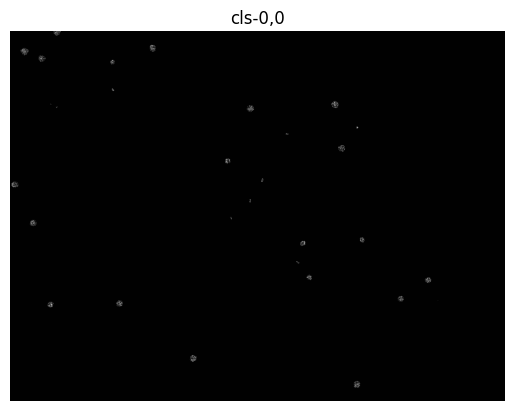

In [11]:
i = 0
j = 0
plt.figure()
plt.axis('off')
plt.title(plate_dirs[0]+"-"+str(i)+","+str(j))
plt.imshow(plate_dict[plate_dirs[0]]['masked_img'][0], cmap='gray')
# plt.savefig("../../../manuscript/figs/masked_plaques_6446_"+str(i)+str(j)+".png",
# bbox_inches='tight', dpi=300)

#### Getting Cellular Object Count
###### Since counting of objects is one of the most basic tasks performed by urologists, we would want to use automated software such as PyPlaque to achieve it. We can do so by instantiating the ```PlaquesMask()``` class for each image (here only the mask of the image being important for the count). We can then use the ```plq_mask.get_plaques()``` function to get the count of the objects in the image. The ```min_area``` and ```max_area``` parameters here can help to look at a different set of objects within the size range of the default value of these parameters can be used.

In [12]:
#Getting count of plaques from the binary masks of the plaques
plaques_mask_gt_list = [PlaquesMask(name = str(plate_dict[plate_dirs[0]]['image_name'][i]),
                                plaques_mask = plate_dict[plate_dirs[0]]['mask'][i]) 
                    for i in tqdm(range(len(plate_dict[plate_dirs[0]]['img'])))]
plaques_count_gt_list = [len(plq_mask.get_plaques(min_area=0, max_area=2000)) for plq_mask in tqdm(plaques_mask_gt_list)]

[print(plq_mask.name, " : ", plq_count, "\n") for (plq_mask, plq_count) 
in tqdm(list(zip(plaques_mask_gt_list, plaques_count_gt_list)))]


100%|██████████| 100/100 [00:00<00:00, 201649.23it/s]

../../../../DeepUTI/ds1/test/img/cls/130 G 261021.tif  :  29 

../../../../DeepUTI/ds1/test/img/cls/130 V 261021.tif  :  32 

../../../../DeepUTI/ds1/test/img/cls/4617 F 051021.tif  :  1 

../../../../DeepUTI/ds1/test/img/cls/5821 C 280921.tif  :  3 

../../../../DeepUTI/ds1/test/img/cls/5830 H 061021.tif  :  0 

../../../../DeepUTI/ds1/test/img/cls/5868 I 280921.tif  :  0 

../../../../DeepUTI/ds1/test/img/cls/6024 I 271021.tif  :  19 

../../../../DeepUTI/ds1/test/img/cls/6032 K 121021.tif  :  25 

../../../../DeepUTI/ds1/test/img/cls/6075 B 280821.tif  :  53 

../../../../DeepUTI/ds1/test/img/cls/6189 J 051021.tif  :  381 

../../../../DeepUTI/ds1/test/img/cls/6189 Z 150921.tif  :  428 

../../../../DeepUTI/ds1/test/img/cls/6316 A 180821.tif  :  6 

../../../../DeepUTI/ds1/test/img/cls/6321 G 080921.tif  :  1 

../../../../DeepUTI/ds1/test/img/cls/6348 O 161121.tif  :  86 

../../../../DeepUTI/ds1/test/img/cls/6372 M 070921.tif  :  1 

../../../../DeepUTI/ds1/test/img/cls/6427 C 280

[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None]

#### Mask Generation Plaques
###### Here we create a new instance of an experiment ```exp2``` where we assume that we do not have the mask of the plaques available. We can tell the experiment to not expect it using the ```read_mask``` flag by setting it to False.Here we take only one image into consideration by using the appropriate ```file_pattern``` regex here. We show the resulting binary virus mask that is formed based on ```params``` that are the default ones used here.

100it [00:00, 117784.44it/s]
100%|██████████| 1/1 [00:00<00:00, 114.01it/s]
100it [00:00, 92773.81it/s]
100%|██████████| 1/1 [00:00<00:00, 93.45it/s]

../../../../DeepUTI/ds1/test/img/cls/4617 F 051021.tif


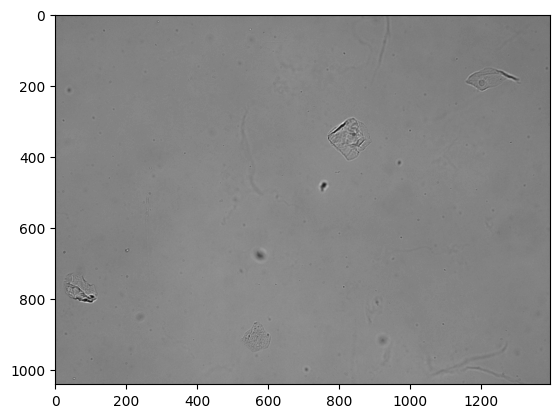

In [13]:
# Getting masks generated from images in case we do not have them already
exp2 = CrystalViolet(base_dir+'img/', base_dir+'man_mask/',
                                        params = None) # default values in class, option to update
_, _ = exp2.get_individual_plates(folder_pattern=r'cls$')
plate_dict_no_mask = exp2.load_well_images_and_masks_for_plate(plate_id=0,
                additional_subfolders=None, all_grayscale=True, ext='*.tif',
                file_pattern=r'4617 F 051021')


print(plate_dict_no_mask[plate_dirs[0]]['image_name'][0])
plt.imshow(plate_dict_no_mask[plate_dirs[0]]['img'][0], cmap='gray')

In [14]:
import numpy as np

print(np.min(plate_dict_no_mask[plate_dirs[0]]['img'][0]))
print(np.max(plate_dict_no_mask[plate_dirs[0]]['img'][0]))

15
252


In [15]:
print(plate_dict[plate_dirs[0]]['image_name'])

[PosixPath('../../../../DeepUTI/ds1/test/img/cls/130 G 261021.tif'), PosixPath('../../../../DeepUTI/ds1/test/img/cls/130 V 261021.tif'), PosixPath('../../../../DeepUTI/ds1/test/img/cls/4617 F 051021.tif'), PosixPath('../../../../DeepUTI/ds1/test/img/cls/5821 C 280921.tif'), PosixPath('../../../../DeepUTI/ds1/test/img/cls/5830 H 061021.tif'), PosixPath('../../../../DeepUTI/ds1/test/img/cls/5868 I 280921.tif'), PosixPath('../../../../DeepUTI/ds1/test/img/cls/6024 I 271021.tif'), PosixPath('../../../../DeepUTI/ds1/test/img/cls/6032 K 121021.tif'), PosixPath('../../../../DeepUTI/ds1/test/img/cls/6075 B 280821.tif'), PosixPath('../../../../DeepUTI/ds1/test/img/cls/6189 J 051021.tif'), PosixPath('../../../../DeepUTI/ds1/test/img/cls/6189 Z 150921.tif'), PosixPath('../../../../DeepUTI/ds1/test/img/cls/6316 A 180821.tif'), PosixPath('../../../../DeepUTI/ds1/test/img/cls/6321 G 080921.tif'), PosixPath('../../../../DeepUTI/ds1/test/img/cls/6348 O 161121.tif'), PosixPath('../../../../DeepUTI/ds1/

../../../../DeepUTI/ds1/test/img/cls/4617 F 051021.tif


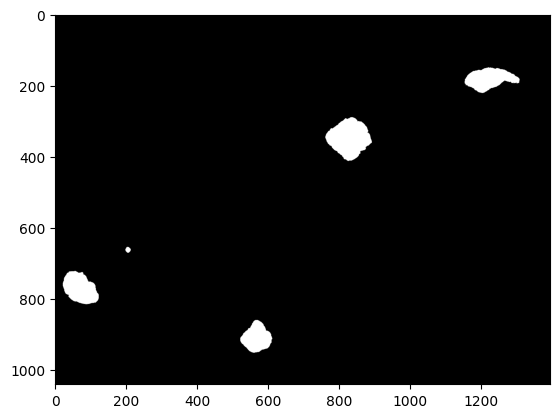

In [16]:
id = 2
print(plate_dict[plate_dirs[0]]['image_name'][id])
plt.imshow(plate_dict[plate_dirs[0]]['mask'][id],cmap='gray')

In [17]:
img_temp = plate_dict_no_mask[plate_dirs[0]]['img'][0]
img_temp = 255 - img_temp
plate_dict_no_mask[plate_dirs[0]]['img'][0] = img_temp

In [18]:
img_gadjusted_list = [adjust_gamma(img,
                                gamma=2.25,
                                gain=exp2.params['crystal_violet']['gain']) 
                            for img in tqdm(plate_dict_no_mask[plate_dirs[0]]['img'])]

mask_list = [PlaquesImageGray(exp2.plate_indiv_dir[0]+"-"+
                                str(i//exp2.params['crystal_violet']['ncols'])+","+
                                str(i%exp2.params['crystal_violet']['ncols']),
                                img_gadjusted_list[i],
                                threshold=exp2.params['crystal_violet']['threshold'],
                                sigma=exp2.params['crystal_violet']['sigma']).plaques_mask
                        for i in tqdm(range(len(plate_dict_no_mask[plate_dirs[0]]['img'])))]

100%|██████████| 1/1 [00:00<00:00, 89.36it/s]


../../../../DeepUTI/ds1/test/img/cls/4617 F 051021.tif


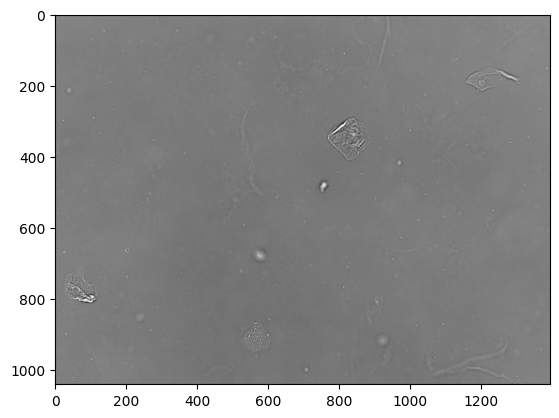

In [19]:
print(plate_dict_no_mask[plate_dirs[0]]['image_name'][0])
plt.imshow(plate_dict_no_mask[plate_dirs[0]]['img'][0], cmap='gray')

../../../../DeepUTI/ds1/test/img/cls/4617 F 051021.tif


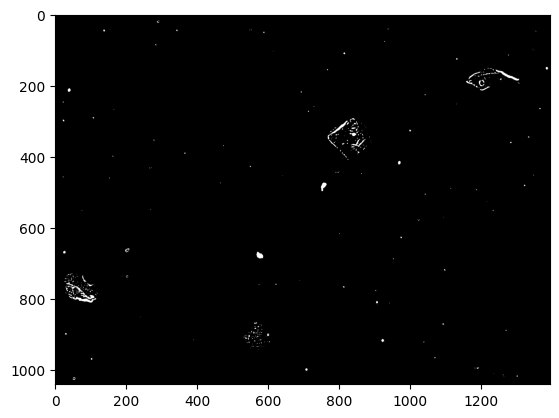

In [20]:
print(plate_dict_no_mask[plate_dirs[0]]['image_name'][0])
plt.imshow(mask_list[0], cmap='gray')

#### Gamma adjustment of images before Mask Generation
###### Here we try to show a comparison of mask generation and therefore plaque detection results by using the raw images in grayscale and a gamma adjusted version of the images using ```adjust_gamma```. Parameters for gamma adjustment are set by default in the experiment but can be changed. We use the ```PlaquesImageGray()``` class to store the grayscale images (gamma adjsuted or otherwise) and then generate the plaque masks using parameters ```threshold``` and ```sigma```. ```plaques_mask_gadjusted_list``` contains the plaques detected from gamma adjusted grayscale images while ```plaques_list``` contains the plaques detected from the raw grayscale images.

In [21]:
#Verifying the count of plaques by generating masks from the images of the plaques themselves, 
# gamma adjusting for better detection
exp.params['crystal_violet']['gamma'] = 2.25
exp.params['crystal_violet']['ncols'] = 10
exp.params['crystal_violet']['nrows'] = 10
exp.params['crystal_violet']['min_area'] = 0
exp.params['crystal_violet']['max_area'] = 500

img_inverted_list = [255-img 
                        for img in tqdm(plate_dict[plate_dirs[0]]['img'])]

img_inverted_gadjusted_list = [adjust_gamma(img, 
                                gamma=exp.params['crystal_violet']['gamma'],
                                gain=exp.params['crystal_violet']['gain']) 
                        for img in tqdm(img_inverted_list)]

plaques_mask_list = [PlaquesImageGray(plate_dirs[0]+"-"+
                                        str(i//exp.params['crystal_violet']['ncols'])+","+
                                        str(i%exp.params['crystal_violet']['ncols']),
                                plate_dict[plate_dirs[0]]['img'][i],
                                threshold=exp.params['crystal_violet']['threshold'],
                                sigma=exp.params['crystal_violet']['sigma']) 
                        for i in tqdm(range(len(plate_dict[plate_dirs[0]]['img'])))]

plaques_list = [plq_mask.get_plaques(min_area = exp.params['crystal_violet']['min_area'], 
                                max_area = exp.params['crystal_violet']['max_area']) 
                    for plq_mask in tqdm(plaques_mask_list)]

plaques_mask_gadjusted_list = [PlaquesImageGray(plate_dirs[0]+"-"+
                                        str(i//exp.params['crystal_violet']['ncols'])+","+
                                        str(i%exp.params['crystal_violet']['ncols']),
                                        img_inverted_gadjusted_list[i],
                                        threshold=exp.params['crystal_violet']['threshold'],
                                        sigma=exp.params['crystal_violet']['sigma']) 
                                for i in tqdm(range(len(plate_dict[plate_dirs[0]]['img'])))]

plaques_gadjusted_list = [plq_mask_gadjusted.get_plaques(
                                                min_area = exp.params['crystal_violet']['min_area'], 
                                                max_area = exp.params['crystal_violet']['max_area']) 
                            for plq_mask_gadjusted in tqdm(plaques_mask_gadjusted_list)]


100%|██████████| 100/100 [00:05<00:00, 18.48it/s]


In [22]:
# for i, (img, img_g) in enumerate(list(zip(plate_dict[plate_dirs[0]]['img'],img_inverted_gadjusted_list))):
#     _, (ax1, ax2) = plt.subplots(1, 2,figsize=(32,8))
#     ax1.imshow(img,cmap='gray')
#     ax1.set_axis_off()
#     ax1.set_title(str(i//exp.params['crystal_violet']['ncols'])+","+str(i%exp.params['crystal_violet']['ncols']))
#     ax2.imshow(img_g,cmap='gray')
#     ax2.set_axis_off()
#     ax2.set_title(str(i//exp.params['crystal_violet']['ncols'])+","+str(i%exp.params['crystal_violet']['ncols'])+" Gamma Adjusted")
#     plt.tight_layout()
#     plt.show()


###### Here we try to visualise the comparison of mask generation and therefore cell detection results by using the raw images in grayscale and a gamma adjusted version of the images using ```compare_plaque_detection_from_image```. Important to note is the counts such as ```cls-0,0  true count``` which is the count obtained for that well from the manually generated best quality plaque masks and therefore our target. Then we have the ones such as ```cls-0,0  :  5``` which is the count of plaques detected from the raw grayscale images and finally the likes of ```cls-0,0  gamma adjusted :  29``` which is the count of plaques detected from the gamma adjusted grayscale images. The plots are alse named similarly as the counts to visualise the location of the plaques detected in each case.

In [23]:
#Plotting the outcome on detection based on the masks
# [compare_plaque_detection_from_image(i//exp.params['crystal_violet']['ncols'],
#                                     i%exp.params['crystal_violet']['ncols'],
#                                     plaques_count_gt_list[i], # from 2 cells above
#                                     plaques_mask_list[i],
#                                     plaques_list[i],
#                                     plaques_mask_gadjusted_list[i],
#                                     plaques_gadjusted_list[i]) 
#                                     for i in tqdm(range(len(plate_dict[plate_dirs[0]]['img'])))]

# save_path = "../../../manuscript/figs/ds1_test_cls_00_plaque_detection_from_image.png"

#### Plaque Bounding Boxes
###### Here we plot the bounding boxes around the detected plaques. The ```.get_plaques()``` function can take different values for ```min_area``` and ```max_area``` to give different results. We show the same bounding boxes around the masked images of the wells further on.

100%|██████████| 6/6 [00:00<00:00, 1031.51it/s]


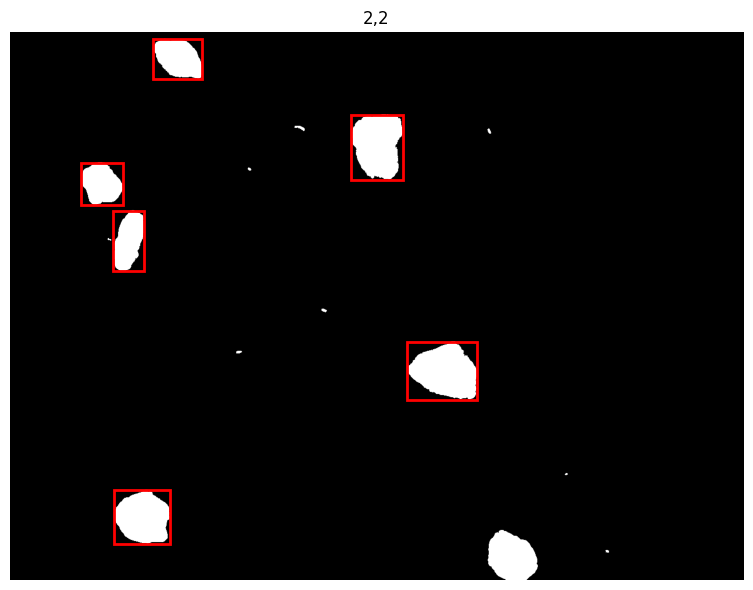

[None]

In [30]:
id = 22
[plot_bbox_plaques_mask(id//exp.params['crystal_violet']['ncols'],
                        id%exp.params['crystal_violet']['ncols'],
                        plaques_mask_gt_list[id].plaques_mask, # from 3 cells above
                        plaques_mask_gt_list[id].get_plaques(min_area = 500, max_area=11000))]

In [31]:
# Plotting bounding boxes around individual cells (in this case from existing binary mask, 
# but could also be done from generated mask)

# [plot_bbox_plaques_mask(i//exp.params['crystal_violet']['ncols'],
#                         i%exp.params['crystal_violet']['ncols'],
#                         plaques_mask_gt_list[i].plaques_mask, # from 3 cells above
#                         plaques_mask_gt_list[i].get_plaques()) 
#                         for i in tqdm(range(len(plaques_mask_gt_list)))]

# save_path = "../../../manuscript/figs/ds1_test_cls_00_plaque_marked.png"

In [32]:
# Here we can use different combinations of minimum and maximum area to indicate different cells
# [plot_bbox_plaques_mask(i//exp.params['crystal_violet']['ncols'],
#                         i%exp.params['crystal_violet']['ncols'],
#                         plate_dict[plate_dirs[0]]['masked_img'][i], # from 3 cells above
#                         plaques_mask_gt_list[i].get_plaques()) 
#                         for i in tqdm(range(len(plaques_mask_list)))]
# save_path = "../../../manuscript/figs/ds1_test_cls_cell_marked.png"

#### Cell Measures
###### It may also be crucial to get other measurements about cells in the micrograph. For this we can use the function ```get_measure()```. It returns measurements such as ```'mean_plq_size'```, ```'med_plq_size'``` etc. We can also use the ```.plot_centroid()``` function to plot the circles around the centroid of the detected plaques and calculated radii and a circumscribing circle around the centroid of all the plaques detected. This will not plot anything in case no plaque is detected.

2 , 2  :  {'mean_plq_size': 6946.333333333333, 'med_plq_size': 6610.0, 'centroid': [414.0833333333333, 419.0], 'mean_plq_ecc': 0.6670829271937957, 'mean_roundness': 0.43670220212147465}


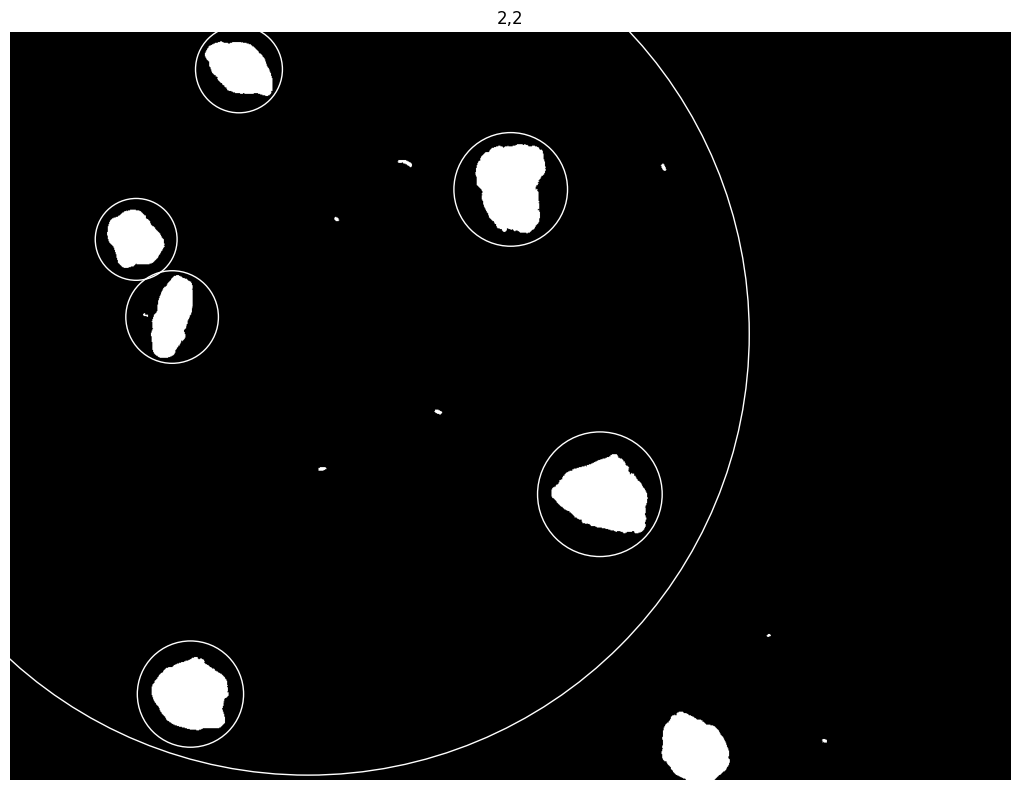

In [40]:
i = 22
# min_area = 0, max_area = 500
# min_area = 500, max_area = 11000

_ = [print(i//exp.params['crystal_violet']['ncols'], ",",
            i%exp.params['crystal_violet']['ncols'], " : ",
            plaques_mask_gt_list[i].get_measure(plaques_mask_gt_list[i].get_plaques(min_area = 500, max_area = 11000)))]

_ = [plaques_mask_gt_list[i].plot_centroid(i//exp.params['crystal_violet']['ncols'],
                            i%exp.params['crystal_violet']['ncols'])]

In [36]:
# Using the package to get some measurements about the cells
# Use different cell sizes to focus on different groups
# _ = [print(i//exp.params['crystal_violet']['ncols'], ",",
#             i%exp.params['crystal_violet']['ncols'], " : ",
#             plaques_mask_gt_list[i].get_measure(plaques_mask_gt_list[i].get_plaques())) 
#             for i in tqdm(range(len(plaques_mask_gt_list)))]

# _ = [plaques_mask_gt_list[i].plot_centroid(i//exp.params['crystal_violet']['ncols'],
#                             i%exp.params['crystal_violet']['ncols']) 
#                             for i in tqdm(range(len(plaques_mask_gt_list)))]

In [ ]:
# Using the package to get some measurements about the cells
# Use different cell sizes to focus on different groups
# _ = [print(i//exp.params['crystal_violet']['ncols'], ",",
#             i%exp.params['crystal_violet']['ncols'], " : ",
#             plaques_mask_gt_list[i].get_measure(plaques_mask_gt_list[i].get_plaques())) 
#             for i in tqdm(range(len(plaques_mask_gt_list)))]

# _ = [plaques_mask_gt_list[i].plot_centroid(i//exp.params['crystal_violet']['ncols'],
#                             i%exp.params['crystal_violet']['ncols']) 
#                             for i in tqdm(range(len(plaques_mask_gt_list)))]

#### Zooming into one Cell
###### Here we take the image from index 0 of the plate dictionary ```plate_dict``` and for that image we get all the plaques, before zooming in into one particular plaque. We choose the plaque located lowest in the well using its centroid and drawing the bounding box around it. Using some offset we are able to zoom in into this one particular plaque and display it. Could be useful if some plaques need special observation.

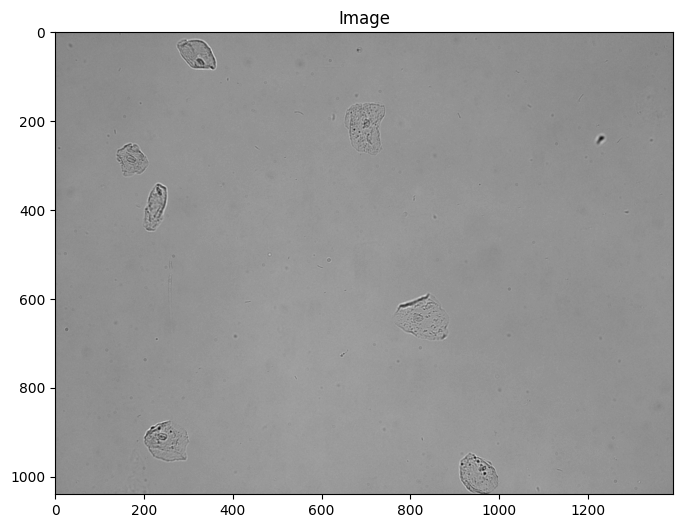

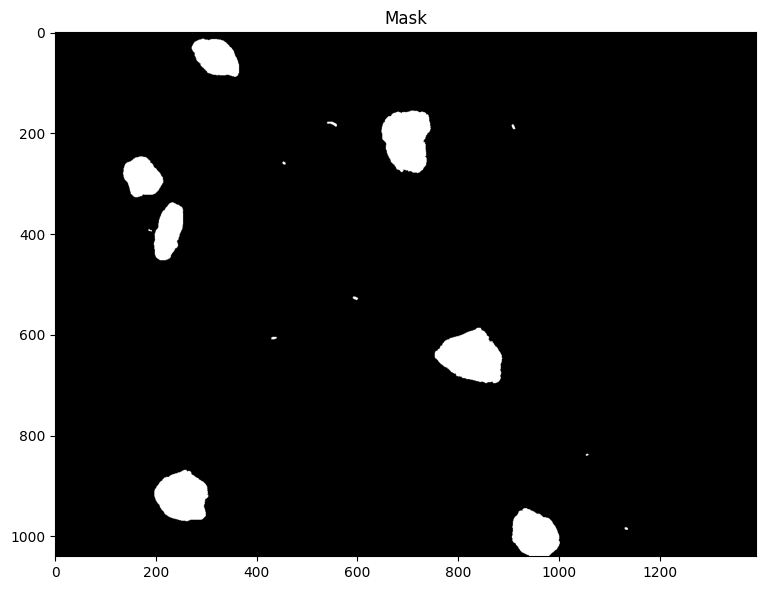

Centroid : (985.0357142857143, 1132.2857142857142)
Area : 35


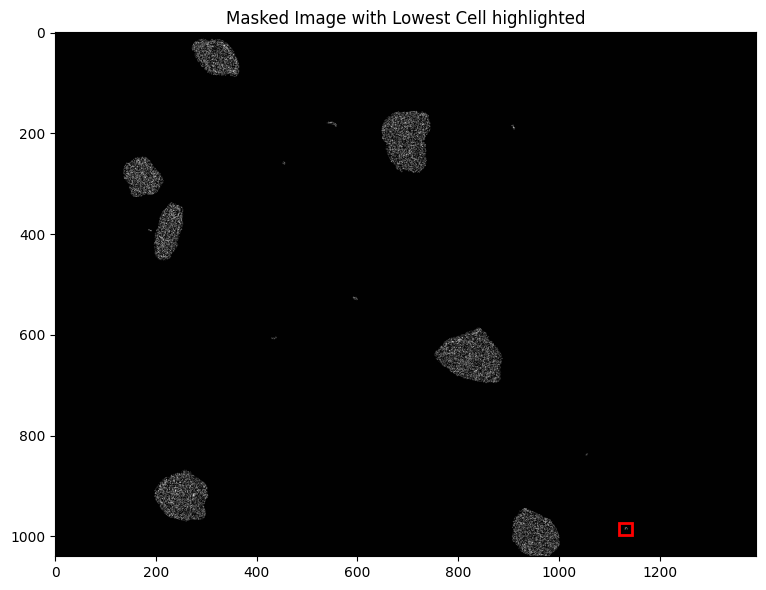

Lowest Cell Centroid : (985.0357142857143, 1132.2857142857142)
Lowest Cell Bounding Box Area : 35


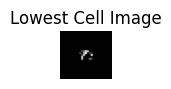

In [48]:
# Zooming in on one individual plaque and its characteristics

# Choosing different valid area range to detect plaques, otherwise default range is used
id = 22
plaques_00 = plaques_mask_gt_list[id].get_plaques(min_area=0, max_area=500)

#Plotting the image of the well
fig, ax = plt.subplots(figsize=(10, 6))
ax.imshow(plate_dict[plate_dirs[0]]['img'][id], cmap='gray')
ax.set_title("Image")

#Plotting the mask of the well
fig, ax = plt.subplots(figsize=(10, 6))
ax.imshow(plate_dict[plate_dirs[0]]['mask'][id], cmap='gray')
ax.set_title("Mask")

plt.tight_layout()
plt.show()

#Finding the lowest plaque in the image and printing its properties
offset = 10
min_y = 0

for plq in plaques_00:
    if (plq.bbox[2] + offset) > min_y:
        min_y = plq.bbox[2] + offset
        lowest_plaque = plq
print('Centroid :', lowest_plaque.centroid)
print('Area :', (lowest_plaque.bbox[3] - lowest_plaque.bbox[1])*
      (lowest_plaque.bbox[2] - lowest_plaque.bbox[0]))

#Finding a bounding box around the lowest plaque in the image
fig, ax = plt.subplots(figsize=(10, 6))
ax.imshow(plate_dict[plate_dirs[0]]['masked_img'][id], cmap='gray')
ax.set_title("Masked Image with Lowest Cell highlighted")

rect = mpatches.Rectangle((lowest_plaque.bbox[1]-offset, lowest_plaque.bbox[0]-offset), 
                          (lowest_plaque.bbox[3]+offset) - (lowest_plaque.bbox[1]-offset), 
                          (lowest_plaque.bbox[2]+offset) - (lowest_plaque.bbox[0]-offset),
                            fill=False, edgecolor='red', linewidth=2)
ax.add_patch(rect)

# plt.savefig("../../../manuscript/figs/ds1_test_cls_lowest_plaque_marked.png",
# bbox_inches='tight', dpi=300)

plt.tight_layout()
plt.show()

# Showing only the plaque we have chosen, the lowest one in the image
lowest_plaque_image = plate_dict[plate_dirs[0]]['masked_img'][id] \
                                [plq.bbox[0]-offset : plq.bbox[2]+offset, 
                                plq.bbox[1]-offset : plq.bbox[3]+offset]

fig, ax = plt.subplots(figsize=(2, 1))
ax.imshow(lowest_plaque_image,cmap='gray')
ax.set_title("Lowest Cell Image")

print('Lowest Cell Centroid :', plq.centroid)
print('Lowest Cell Bounding Box Area :', (plq.bbox[3] - plq.bbox[1])*(plq.bbox[2] - plq.bbox[0]))

# plt.savefig("../../../manuscript/figs/ds1_test_cls_00_lowest.png", bbox_inches='tight', dpi=300)

ax.set_axis_off()
plt.tight_layout()
plt.show()

#### Cell Measures Visualisation
###### It may also be crucial to visualise measurements about cells in the micrographs. For this we can get the measurements into a dataframe and then use boxplots to visualise it. The values of the boxplot upper and lower bounds, q1, q2 and q3 can all be obtained separately too if viewing it in the plot is not convenient.

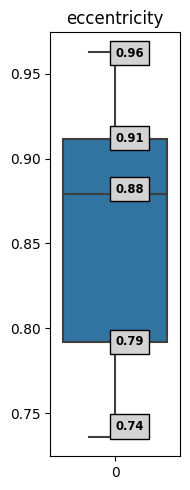

   whishi  whislo    q1   med    q3
0    0.96    0.74  0.79  0.88  0.91


In [49]:
# Other plots we can get about the plaques in a wells

ecc_ls = [plq.eccentricity() for plq in plaques_00]
roundness_ls = [plq.roundness() for plq in plaques_00]
plq_measures_df = pd.DataFrame()
plq_measures_df['eccentricity'] = ecc_ls
plq_measures_df['roundness'] = roundness_ls

stats = boxplot_quants(plq_measures_df,col_name='eccentricity',return_stats=True)
print(stats)